In [16]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Import pandas_ta for the technical math
try:
    import pandas_ta as ta
except ImportError:
    !pip install pandas_ta
    import pandas_ta as ta

# Download AAPL data
ticker = 'AAPL'
df_stock = yf.download(ticker, start='2015-01-01', end='2021-01-01')

# Clean multi-index columns if they exist
if isinstance(df_stock.columns, pd.MultiIndex):
    df_stock.columns = df_stock.columns.get_level_values(0)

print(f"✅ Data for {ticker} loaded!")
df_stock.head()

C:\Users\mekli\AppData\Local\Temp\ipykernel_4888\682233936.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_stock = yf.download(ticker, start='2015-01-01', end='2021-01-01')
C:\Users\mekli\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


✅ Data for AAPL loaded!


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.214890,24.682222,23.776350,24.671147,212818400
2015-01-05,23.532719,24.064282,23.346673,23.984547,257142000
2015-01-06,23.534939,23.794075,23.173918,23.596954,263188400
2015-01-07,23.864946,23.964614,23.632387,23.743129,160423600
2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000


In [17]:
# 1. Simple Moving Average (20-day)
df_stock['SMA_20'] = ta.sma(df_stock['Close'], length=20)

# 2. Relative Strength Index (RSI)
df_stock['RSI_14'] = ta.rsi(df_stock['Close'], length=14)

# 3. MACD (Moving Average Convergence Divergence)
macd_data = ta.macd(df_stock['Close'])
df_stock = pd.concat([df_stock, macd_data], axis=1)

print("✅ Technical Indicators Calculated!")
# This shows us the names of our new columns to make sure they exist
print(df_stock.columns.tolist())

✅ Technical Indicators Calculated!
['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9']


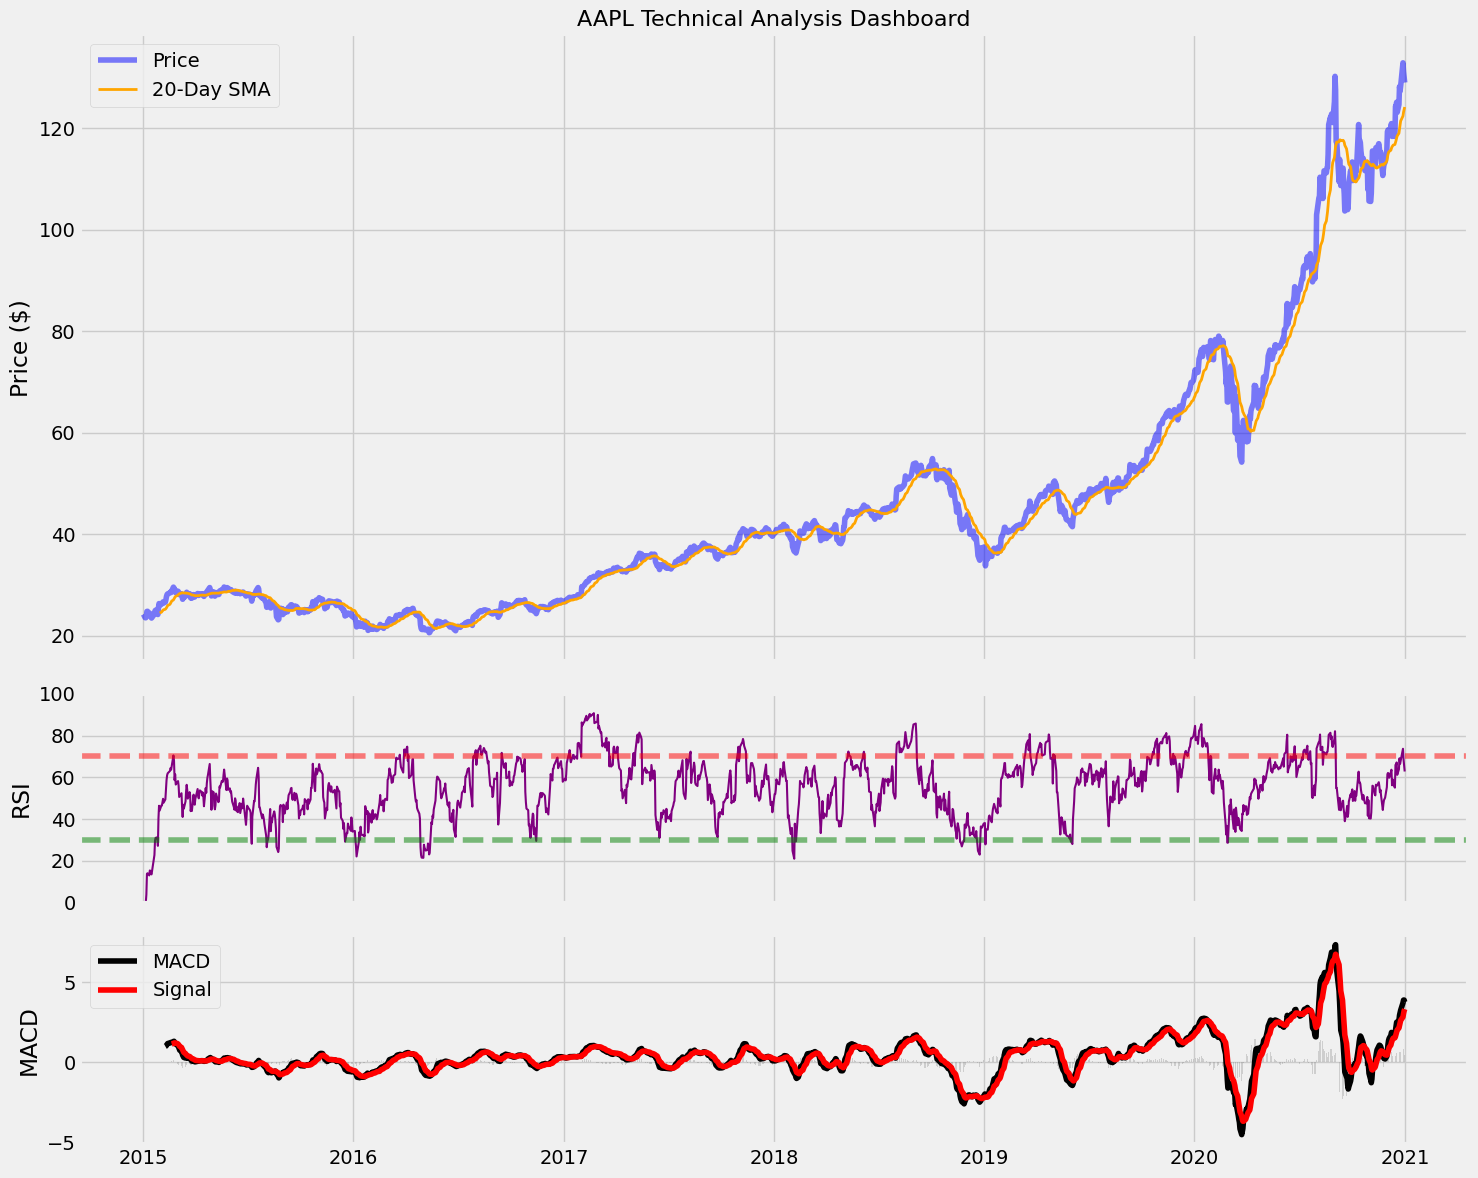

In [18]:
# Set the style to look professional
plt.style.use('fivethirtyeight')

# Create 3 subplots stacked on top of each other
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True, 
                                     gridspec_kw={'height_ratios': [3, 1, 1]})

# --- TOP PANEL: Price and SMA ---
ax1.plot(df_stock.index, df_stock['Close'], label='Price', color='blue', alpha=0.5)
ax1.plot(df_stock.index, df_stock['SMA_20'], label='20-Day SMA', color='orange', lw=2)
ax1.set_title(f'{ticker} Technical Analysis Dashboard', fontsize=16)
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')

# --- MIDDLE PANEL: RSI ---
ax2.plot(df_stock.index, df_stock['RSI_14'], color='purple', lw=1.5)
ax2.axhline(70, color='red', linestyle='--', alpha=0.5) # Overbought Line
ax2.axhline(30, color='green', linestyle='--', alpha=0.5) # Oversold Line
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)

# --- BOTTOM PANEL: MACD ---
ax3.plot(df_stock.index, df_stock['MACD_12_26_9'], label='MACD', color='black')
ax3.plot(df_stock.index, df_stock['MACDs_12_26_9'], label='Signal', color='red')
ax3.bar(df_stock.index, df_stock['MACDh_12_26_9'], color='gray', alpha=0.3)
ax3.set_ylabel('MACD')
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()